   day_number   day_name  listing_nights  avg_observed_pct  avg_expected_pct  \
0           1     Monday           68750              27.0              30.6   
1           2    Tuesday           68952              27.0              30.4   
2           3  Wednesday           68952              28.0              30.2   
3           4   Thursday           68952              30.2              29.9   
4           5     Friday           68067              34.2              29.8   
5           6   Saturday           66502              35.0              29.8   
6           7     Sunday           67185              29.4              30.0   

   avg_excess_pct  
0            -3.5  
1            -3.4  
2            -2.2  
3             0.3  
4             4.4  
5             5.3  
6            -0.6  


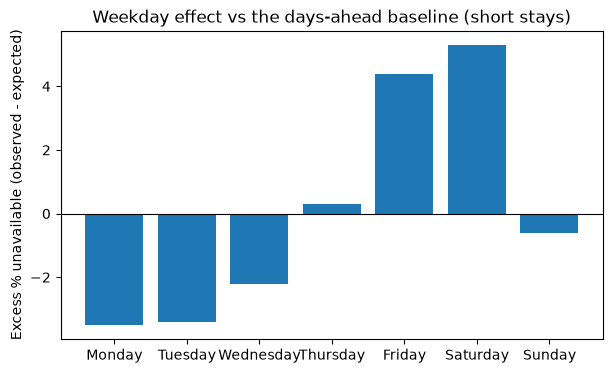

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

weekday = duckdb.sql(
    "SELECT * FROM read_parquet('../data/gold/nyc/weekday_adjustment.parquet')"
).df().sort_values("day_number")

print(weekday)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weekday["day_name"], weekday["avg_excess_pct"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Weekday effect vs the days-ahead baseline (short stays)")
ax.set_ylabel("Excess % unavailable (observed - expected)")
plt.show()

In [5]:
dates = duckdb.sql(
    "SELECT * FROM read_parquet('../data/gold/nyc/date_adjustment.parquet')"
).df()

top = dates.sort_values("excess_pct", ascending=False).head(20)
print(top.to_string(index=False))

calendar_date  day_name  listing_nights  avg_observed_pct  avg_expected_pct  excess_pct
   2026-07-18  Saturday            2652              63.8              47.2        16.6
   2026-06-27  Saturday            2652              71.8              57.3        14.5
   2026-07-11  Saturday            2652              55.0              43.6        11.4
   2026-06-26    Friday            2652              69.8              58.8        11.0
   2026-06-20  Saturday            2450              71.3              60.7        10.6
   2026-07-19    Sunday            2652              56.4              46.4        10.0
   2026-07-17    Friday            2652              56.9              47.2         9.7
   2026-10-31  Saturday            2652              33.3              23.9         9.4
   2026-07-04  Saturday            2652              55.1              46.3         8.8
   2026-07-10    Friday            2652              52.3              44.1         8.3
   2026-09-05  Saturday         

In [ ]:
# Quick separate check: does a similar weekday pattern appear for monthly stays?
# (We expect NO effect here, since a 30-night stay covers every weekday anyway)
monthly_check = duckdb.sql("""
    WITH ml AS (
        SELECT listing_id FROM read_parquet('../data/gold/nyc/listings_prepared.parquet')
        WHERE base_price IS NOT NULL AND stay_type = 'monthly stay'
    ),
    ol AS (
        SELECT listing_id FROM read_parquet('../data/silver/nyc/calendar.parquet')
        WHERE days_from_start >= 330 GROUP BY listing_id HAVING BOOL_OR(is_available)
    )
    SELECT
        ISODOW(c.calendar_date) AS day_number,
        DAYNAME(c.calendar_date) AS day_name,
        ROUND(AVG(CASE WHEN c.is_available THEN 0.0 ELSE 100.0 END), 1) AS pct_unavailable
    FROM read_parquet('../data/silver/nyc/calendar.parquet') c
    JOIN ml ON ml.listing_id = c.listing_id
    JOIN ol ON ol.listing_id = c.listing_id
    WHERE c.days_from_start < 180
    GROUP BY 1, 2 ORDER BY 1
""").df()
print(monthly_check)

   day_number   day_name  pct_unavailable
0           1     Monday             31.1
1           2    Tuesday             30.8
2           3  Wednesday             30.5
3           4   Thursday             30.4
4           5     Friday             30.6
5           6   Saturday             30.3
6           7     Sunday             31.3
